# Test de Cointégration BTC vs ETH

Téléchargement de BTC/USDT...
Téléchargement de ETH/USDT...

Données alignées : 500 bougies.
------------------------------------------------------------
Test Statistique : -2.7384
P-Value du test : 0.1861
❌ ÉCHEC : La P-Value est >= 0.05.
Les actifs dérivent trop l'un de l'autre en ce moment.


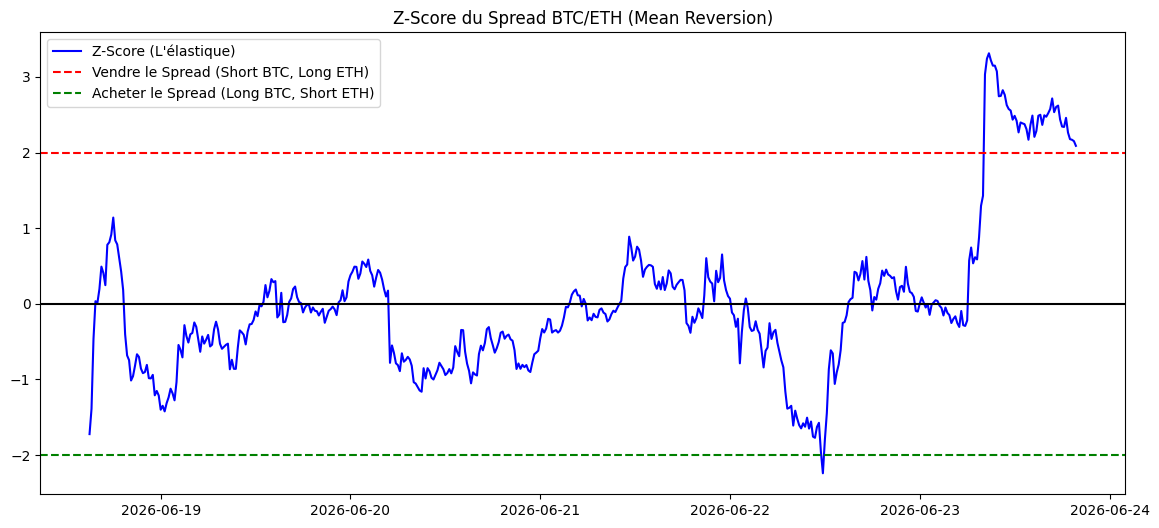

In [2]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

def fetch_data(symbol, timeframe='1h', limit=1000):
    """Télécharge l'historique des prix depuis Binance."""
    exchange = ccxt.binance()
    print(f"Téléchargement de {symbol}...")
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

# 1. Récupération des données (1000 dernières heures)
try:
    # Modifie les paramètres de fetch_data
    btc = fetch_data('BTC/USDT', timeframe='15m', limit=500)
    eth = fetch_data('ETH/USDT', timeframe='15m', limit=500)
except Exception as e:
    print(f"Erreur de téléchargement : {e}")

# 2. Alignement strict des données
df = pd.concat([btc, eth], axis=1).dropna()
df.columns = ['BTC', 'ETH']

print(f"\nDonnées alignées : {len(df)} bougies.")

# 3. Le Test Statistique (Engle-Granger)
score, p_value, _ = coint(df['BTC'], df['ETH'])

print("-" * 60)
print(f"Test Statistique : {score:.4f}")
print(f"P-Value du test : {p_value:.4f}")

if p_value < 0.05:
    print("✅ SUCCÈS : La P-Value est < 0.05.")
    print("Les deux actifs sont mathématiquement COINTÉGRÉS.")
else:
    print("❌ ÉCHEC : La P-Value est >= 0.05.")
    print("Les actifs dérivent trop l'un de l'autre en ce moment.")

# 4. Calcul du Spread et Z-Score
# Spread = BTC - (ratio * ETH)
ratio = df['BTC'].mean() / df['ETH'].mean()
spread = df['BTC'] - (ratio * df['ETH'])
zscore = (spread - spread.mean()) / spread.std()

# 5. Visualisation
plt.figure(figsize=(14, 6))
plt.plot(zscore, label="Z-Score (L'élastique)", color='blue')
plt.axhline(2.0, color='red', linestyle='--', label='Vendre le Spread (Short BTC, Long ETH)')
plt.axhline(-2.0, color='green', linestyle='--', label='Acheter le Spread (Long BTC, Short ETH)')
plt.axhline(0, color='black', linestyle='-')
plt.title('Z-Score du Spread BTC/ETH (Mean Reversion)')
plt.legend()
plt.show()

In [4]:
import ccxt
import pandas as pd
import itertools
from statsmodels.tsa.stattools import coint

def fetch_closes(symbols, timeframe, limit=500):
    exchange = ccxt.binance()
    df_main = pd.DataFrame()
    
    for sym in symbols:
        print(f"Aspiration de {sym}...")
        try:
            ohlcv = exchange.fetch_ohlcv(sym, timeframe, limit=limit)
            df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            df.set_index('timestamp', inplace=True)
            df_main[sym] = df['close']
        except Exception as e:
            print(f"Erreur sur {sym}: {e}")
            
    return df_main.dropna()

print("="*60)
print("🔍 RADAR DE COINTÉGRATION HAUTE FRÉQUENCE")
print("="*60)

# On teste le secteur des Layer 2 et des "Blue Chips" DeFi
universe = ['ARB/USDT', 'OP/USDT', 'UNI/USDT', 'AAVE/USDT', 'LDO/USDT', 'ETH/USDT', 'BTC/USDT', 'ETH/USDT', 'LTC/USDT', 'SOL/USDT', 'XRP/USDT']

# 1. On aspire tout
df_universe15m = fetch_closes(universe, timeframe='15m', limit=500)
df_universe1h = fetch_closes(universe, timeframe='1h', limit=500)

# 2. On génère toutes les paires possibles (ex: ARB vs OP, UNI vs AAVE...)
pairs = list(itertools.combinations(df_universe15m.columns, 2))
results = []
pairs1h = list(itertools.combinations(df_universe1h.columns, 2))
results1h = []

# 3. On teste la cointégration pour chaque paire
for sym1, sym2 in pairs:
    score, p_value, _ = coint(df_universe15m[sym1], df_universe15m[sym2])
    results.append({'Paire': f"{sym1} vs {sym2}", 'P-Value': p_value})

for sym1, sym2 in pairs1h:
    score, p_value, _ = coint(df_universe1h[sym1], df_universe1h[sym2])
    results1h.append({'Paire': f"{sym1} vs {sym2}", 'P-Value': p_value})

# 4. On classe du meilleur (plus petite P-Value) au pire
df_results = pd.DataFrame(results).sort_values(by='P-Value')
df_results1h = pd.DataFrame(results1h).sort_values(by='P-Value')

print("\n🏆 CLASSEMENT DES PAIRES (Recherche P-Value < 0.05) :")
print("-" * 60)
for index, row in df_results.iterrows():
    status = "✅ JOUABLE" if row['P-Value'] < 0.05 else "❌ REJETÉ"
    print(f"{row['Paire']:<25} | P-Value: {row['P-Value']:.4f} | {status}")

print("\n🏆 CLASSEMENT DES PAIRES 1H (Recherche P-Value < 0.05) :")
print("-" * 60)
for index, row in df_results1h.iterrows():
    status = "✅ JOUABLE" if row['P-Value'] < 0.05 else "❌ REJETÉ"
    print(f"{row['Paire']:<25} | P-Value: {row['P-Value']:.4f} | {status}")

🔍 RADAR DE COINTÉGRATION HAUTE FRÉQUENCE
Aspiration de ARB/USDT...
Aspiration de OP/USDT...
Aspiration de UNI/USDT...
Aspiration de AAVE/USDT...
Aspiration de LDO/USDT...
Aspiration de ETH/USDT...
Aspiration de BTC/USDT...
Aspiration de ETH/USDT...
Aspiration de LTC/USDT...
Aspiration de SOL/USDT...
Aspiration de XRP/USDT...
Aspiration de ARB/USDT...
Aspiration de OP/USDT...
Aspiration de UNI/USDT...
Aspiration de AAVE/USDT...
Aspiration de LDO/USDT...
Aspiration de ETH/USDT...
Aspiration de BTC/USDT...
Aspiration de ETH/USDT...
Aspiration de LTC/USDT...
Aspiration de SOL/USDT...
Aspiration de XRP/USDT...

🏆 CLASSEMENT DES PAIRES (Recherche P-Value < 0.05) :
------------------------------------------------------------
AAVE/USDT vs ETH/USDT     | P-Value: 0.0007 | ✅ JOUABLE
AAVE/USDT vs BTC/USDT     | P-Value: 0.0027 | ✅ JOUABLE
AAVE/USDT vs LTC/USDT     | P-Value: 0.0155 | ✅ JOUABLE
UNI/USDT vs LDO/USDT      | P-Value: 0.0169 | ✅ JOUABLE
AAVE/USDT vs SOL/USDT     | P-Value: 0.0339 | ✅ 

In [5]:
import ccxt
import pandas as pd
import numpy as np
import statsmodels.api as sm

def fetch_data(symbol, timeframe='15m', limit=1000):
    exchange = ccxt.binance()
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

def calculate_hurst_exponent(ts):
    """Calcule l'Exposant de Hurst d'une série temporelle."""
    lags = range(2, 100)
    # Calcul de la variance des différences pour chaque lag
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # Régression linéaire sur l'échelle log-log
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    # Le Hurst Exponent est approximativement la pente * 2
    return poly[0] * 2.0

print("="*60)
print("🔬 STRESS-TESTS QUANTITATIFS : AAVE vs ETH (15m)")
print("="*60)

# 1. Téléchargement et alignement
sym1, sym2 = 'AAVE/USDT', 'ETH/USDT'
print("Téléchargement des données (1000 bougies)...")
df1 = fetch_data(sym1, timeframe='15m', limit=1000)
df2 = fetch_data(sym2, timeframe='15m', limit=1000)

df = pd.concat([df1, df2], axis=1).dropna()
df.columns = [sym1, sym2]

# 2. Calcul du Spread et Z-Score
ratio = df[sym1].mean() / df[sym2].mean()
spread = df[sym1] - (ratio * df[sym2])
zscore = (spread - spread.mean()) / spread.std()

# --- TEST 1 : LA DEMI-VIE (Half-Life) ---
# On utilise la régression linéaire sur le spread décalé (Processus d'Ornstein-Uhlenbeck)
spread_lag = spread.shift(1).dropna()
spread_diff = spread.diff().dropna()
spread_lag = spread_lag[spread_diff.index]

X = sm.add_constant(spread_lag)
model = sm.OLS(spread_diff, X)
results = model.fit()
lambda_val = results.params.iloc[1] # Le coefficient de retour à la moyenne

# Si lambda est positif, la série diverge (pas de demi-vie)
if lambda_val >= 0:
    half_life = float('inf')
else:
    half_life = -np.log(2) / lambda_val

# --- TEST 2 : HURST EXPONENT ---
hurst = calculate_hurst_exponent(spread.values)

# --- TEST 3 : CROISEMENTS DE ZÉRO ---
# On compte combien de fois le Z-Score passe de positif à négatif (ou inversement)
zero_crossings = ((zscore.shift(1) * zscore) < 0).sum()

# --- TEST 4 : AMPLITUDE VS FRAIS ---
# De quel pourcentage le prix diverge-t-il quand le Z-Score touche +2 ?
# Spread à +2 σ = 2 * Ecart-Type
divergence_valeur = 2 * spread.std()
# En pourcentage par rapport au prix moyen de AAVE
amplitude_pct = (divergence_valeur / df[sym1].mean()) * 100

# ==========================================
# AFFICHAGE DES RÉSULTATS DU BULLETIN DE NOTES
# ==========================================
print("\n📋 RÉSULTATS DES TESTS :")
print("-" * 60)

# 1. Demi-Vie
hl_status = "✅ EXCELLENT" if 2 <= half_life <= 50 else "❌ DANGEREUX"
print(f"1. Demi-Vie (Half-Life)   : {half_life:.2f} bougies ({half_life * 15 / 60:.1f} heures) | {hl_status}")

# 2. Hurst
hurst_status = "✅ MEAN-REVERTING" if hurst < 0.5 else "❌ TENDANCE (DANGER)"
print(f"2. Exposant de Hurst      : {hurst:.4f} | {hurst_status}")

# 3. Zéro-Crossings
cross_status = "✅ TRÈS ACTIF" if zero_crossings > 15 else "❌ TROP STATIQUE"
print(f"3. Croisements du Zéro    : {zero_crossings} fois sur 1000 bougies | {cross_status}")

# 4. Amplitude
frais_totaux = 0.20 # 0.05% * 4 (Achat A, Vente B, Vente A, Achat B)
amp_status = "✅ VIABLE" if amplitude_pct > (frais_totaux * 2) else "❌ MANGÉ PAR LES FRAIS"
print(f"4. Amplitude à Z=+2       : {amplitude_pct:.2f}% de divergence | {amp_status}")
print(f"   (Frais minimums requis : ~{frais_totaux:.2f}%)")
print("-" * 60)

🔬 STRESS-TESTS QUANTITATIFS : AAVE vs ETH (15m)
Téléchargement des données (1000 bougies)...

📋 RÉSULTATS DES TESTS :
------------------------------------------------------------
1. Demi-Vie (Half-Life)   : 108.36 bougies (27.1 heures) | ❌ DANGEREUX
2. Exposant de Hurst      : 0.2948 | ✅ MEAN-REVERTING
3. Croisements du Zéro    : 31 fois sur 1000 bougies | ✅ TRÈS ACTIF
4. Amplitude à Z=+2       : 6.40% de divergence | ✅ VIABLE
   (Frais minimums requis : ~0.20%)
------------------------------------------------------------
